<a href="https://colab.research.google.com/github/mdjoshi26/gene-sematic-bridge/blob/main/DL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preprocessing**

In [ ]:
!pip install scanpy
!pip install torch
!pip install mygene -q
import scanpy as sc
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn.functional as F
import json
import pickle
import torch.nn as nn
import torch.optim as optim


import mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.9 MB/s eta 0:00:00


In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print('Setup complete!')

Device: cuda
Setup complete!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = '/content/drive/MyDrive/DL_Project_files/data'

In [ ]:
SPLITS_DIR = '/content/drive/MyDrive/DL_Project_files/data/splits_norman/'

In [ ]:
OUTPUT_DIR   = '/content/drive/MyDrive/DL_Project_files/data/output'

In [ ]:
adata = sc.read_h5ad(f'{DATA_DIR}/norman.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 91205 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'


In [ ]:
conditions = list(adata.obs['condition'].unique())
single_perts = [c for c in conditions if '+ctrl' in c or 'ctrl+' in c]
dual_perts = [c for c in conditions if '+' in c and 'ctrl' not in c]
n_ctrl_cells = (adata.obs['control'] == 1).sum()

In [ ]:
print(f"""
PERTURBATION STRUCTURE
Control cells:             {n_ctrl_cells:,} cells (baseline, no perturbation)
Single-gene perturbations: {len(single_perts)} conditions (e.g., "CBL+ctrl")
Dual-gene perturbations:   {len(dual_perts)} conditions (e.g., "CBL+UBASH3B")

Examples:
  Single: {single_perts[:3]}
  Dual:   {dual_perts[:3]}
""")


PERTURBATION STRUCTURE
Control cells:             7,353 cells (baseline, no perturbation)
Single-gene perturbations: 152 conditions (e.g., "CBL+ctrl")
Dual-gene perturbations:   131 conditions (e.g., "CBL+UBASH3B")

Examples:
  Single: ['TSC22D1+ctrl', 'MAML2+ctrl', 'ctrl+CEBPE']
  Dual:   ['KLF1+MAP2K6', 'CEBPE+RUNX1T1', 'CBL+PTPN9']



In [ ]:
print("X dtype:", adata.X.dtype)
print("X shape:", adata.X.shape)
print("X min/max:", adata.X.min(), adata.X.max())
print("Is sparse:", hasattr(adata.X, 'toarray'))
print()

X dtype: float32
X shape: (91205, 5045)
X min/max: 0.0 8.90458
Is sparse: True



In [ ]:
for split_type in ['simulation', 'combo_seen0', 'combo_seen1', 'combo_seen2']:
    try:
        masks = pd.read_csv(f'{SPLITS_DIR}split_{split_type}.csv')
        print(f"split_{split_type}:")
        print(f"  columns: {masks.columns.tolist()}")
        print(f"  sizes:   {masks.sum().to_dict()}")
        print()
    except FileNotFoundError:
        print(f"split_{split_type}.csv — NOT FOUND, check filename")

split_simulation:
  columns: ['train', 'val', 'test']
  sizes:   {'train': 49849, 'val': 10754, 'test': 28754}

split_combo_seen0:
  columns: ['train', 'val', 'test']
  sizes:   {'train': 65564, 'val': 5025, 'test': 5830}

split_combo_seen1:
  columns: ['train', 'val', 'test']
  sizes:   {'train': 65564, 'val': 12171, 'test': 11622}

split_combo_seen2:
  columns: ['train', 'val', 'test']
  sizes:   {'train': 82784, 'val': 3575, 'test': 2998}



In [ ]:
masks = pd.read_csv(f'{SPLITS_DIR}split_simulation.csv')

# Check what it looks like
print(masks.head(10))
print()
print("Columns:", masks.columns.tolist())
print("Shape:", masks.shape)
print("Dtypes:", masks.dtypes.to_dict())

   train    val   test
0   True  False  False
1  False   True  False
2   True  False  False
3   True  False  False
4   True  False  False
5   True  False  False
6   True  False  False
7  False  False   True
8  False   True  False
9   True  False  False

Columns: ['train', 'val', 'test']
Shape: (91205, 3)
Dtypes: {'train': dtype('bool'), 'val': dtype('bool'), 'test': dtype('bool')}


In [ ]:
masks = pd.read_csv(f'{SPLITS_DIR}split_combo_seen0.csv')

# Check what it looks like
print(masks.head(10))
print()
print("Columns:", masks.columns.tolist())
print("Shape:", masks.shape)
print("Dtypes:", masks.dtypes.to_dict())

   train    val   test
0   True  False  False
1   True  False  False
2   True  False  False
3  False  False  False
4   True  False  False
5  False   True  False
6   True  False  False
7  False  False  False
8   True  False  False
9  False  False  False

Columns: ['train', 'val', 'test']
Shape: (91205, 3)
Dtypes: {'train': dtype('bool'), 'val': dtype('bool'), 'test': dtype('bool')}


In [ ]:
masks = pd.read_csv(f'{SPLITS_DIR}split_combo_seen1.csv')

# Check what it looks like
print(masks.head(10))
print()
print("Columns:", masks.columns.tolist())
print("Shape:", masks.shape)
print("Dtypes:", masks.dtypes.to_dict())

   train    val   test
0   True  False  False
1   True  False  False
2   True  False  False
3  False   True  False
4   True  False  False
5  False   True  False
6   True  False  False
7  False  False   True
8   True  False  False
9  False   True  False

Columns: ['train', 'val', 'test']
Shape: (91205, 3)
Dtypes: {'train': dtype('bool'), 'val': dtype('bool'), 'test': dtype('bool')}


In [ ]:
masks = pd.read_csv(f'{SPLITS_DIR}split_combo_seen2.csv')

# Check what it looks like
print(masks.head(10))
print()
print("Columns:", masks.columns.tolist())
print("Shape:", masks.shape)
print("Dtypes:", masks.dtypes.to_dict())

   train    val   test
0   True  False  False
1  False   True  False
2   True  False  False
3  False   True  False
4   True  False  False
5   True  False  False
6   True  False  False
7   True  False  False
8   True  False  False
9   True  False  False

Columns: ['train', 'val', 'test']
Shape: (91205, 3)
Dtypes: {'train': dtype('bool'), 'val': dtype('bool'), 'test': dtype('bool')}


In [ ]:
results = {}

for split_type in ['simulation', 'combo_seen2', 'combo_seen1', 'combo_seen0']:
    masks = pd.read_csv(f'{SPLITS_DIR}split_{split_type}.csv')

    train_adata = adata[masks['train'].values]
    val_adata   = adata[masks['val'].values]
    test_adata  = adata[masks['test'].values]

    print(f"\n{'='*50}")
    print(f"Split: {split_type}")
    print(f"  Train: {train_adata.n_obs:,} cells")
    print(f"  Val:   {val_adata.n_obs:,} cells")
    print(f"  Test:  {test_adata.n_obs:,} cells")

    results[split_type] = {
        'train': train_adata,
        'val':   val_adata,
        'test':  test_adata
    }


Split: simulation
  Train: 49,849 cells
  Val:   10,754 cells
  Test:  28,754 cells

Split: combo_seen2
  Train: 82,784 cells
  Val:   3,575 cells
  Test:  2,998 cells

Split: combo_seen1
  Train: 65,564 cells
  Val:   12,171 cells
  Test:  11,622 cells

Split: combo_seen0
  Train: 65,564 cells
  Val:   5,025 cells
  Test:  5,830 cells


# STEP 1 — PREPROCESSING


## 1. Verify Expression Matrix

In [ ]:
# Check what adata.X contains
X_sample = adata.X[:200]
if hasattr(X_sample, 'toarray'):
    X_sample = X_sample.toarray()

print('Expression matrix (adata.X):')
print(f'  dtype:    {adata.X.dtype}')
print(f'  is sparse:{hasattr(adata.X, "toarray")}')
print(f'  min:      {X_sample.min():.3f}')
print(f'  max:      {X_sample.max():.3f}')
print(f'  mean:     {X_sample.mean():.3f}')
print(f'  sparsity: {(X_sample == 0).mean()*100:.1f}% zeros')
print()
print('  → Values between 0-10 = log-normalised ✓')
print('  → High sparsity (>80%) is normal for scRNA-seq ✓')

Expression matrix (adata.X):
  dtype:    float32
  is sparse:True
  min:      0.000
  max:      7.182
  mean:     0.106
  sparsity: 92.0% zeros

  → Values between 0-10 = log-normalised ✓
  → High sparsity (>80%) is normal for scRNA-seq ✓


In [ ]:
import matplotlib.pyplot as plt


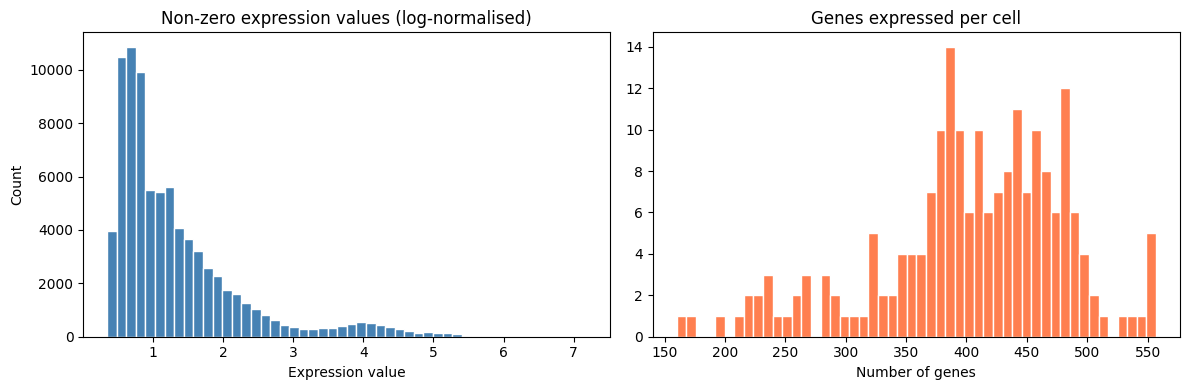

In [ ]:
# Plot expression distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

nonzero = X_sample[X_sample > 0].flatten()
axes[0].hist(nonzero, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Non-zero expression values (log-normalised)')
axes[0].set_xlabel('Expression value')
axes[0].set_ylabel('Count')

genes_per_cell = (X_sample > 0).sum(axis=1)
axes[1].hist(genes_per_cell, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Genes expressed per cell')
axes[1].set_xlabel('Number of genes')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/expression_distribution.png', dpi=100)
plt.show()

## 2. Compute Control Mean (Basal State)

In [ ]:
# Control mean = average expression of unperturbed cells
# This is the 'basal state' — what a cell looks like with no perturbation
# IMPORTANT: compute from TRAIN controls only, never from val/test

ctrl_train_mask = train_adata.obs['control'] == 1
ctrl_train      = train_adata[ctrl_train_mask]

ctrl_X = ctrl_train.X
if hasattr(ctrl_X, 'toarray'):
    ctrl_X = ctrl_X.toarray()

ctrl_mean        = ctrl_X.mean(axis=0)               # shape: (5045,)
ctrl_mean_tensor = torch.tensor(ctrl_mean, dtype=torch.float32)

print(f'Control cells in train: {ctrl_train_mask.sum():,}')
print(f'ctrl_mean shape:        {ctrl_mean.shape}')
print(f'ctrl_mean min/max:      {ctrl_mean.min():.3f} / {ctrl_mean.max():.3f}')

# Save for later use
np.save(f'{OUTPUT_DIR}/ctrl_mean.npy', ctrl_mean)
print('\nSaved ctrl_mean.npy to Drive ✓')

Control cells in train: 7,353
ctrl_mean shape:        (5045,)
ctrl_mean min/max:      0.000 / 5.144

Saved ctrl_mean.npy to Drive ✓


## 3. Extract Perturbed Gene List

In [ ]:
def parse_condition(cond):
    """Extract gene names from condition string.
    'CBL+ctrl'     → ['CBL']
    'CBL+UBASH3B'  → ['CBL', 'UBASH3B']
    'ctrl'         → []
    """
    parts = cond.split('+')
    return [p for p in parts if p != 'ctrl']


In [ ]:
# Get all unique perturbed genes
all_perturbed_genes = set()
for cond in adata.obs['condition'].unique():
    for gene in parse_condition(cond):
        all_perturbed_genes.add(gene)

all_perturbed_genes = sorted(all_perturbed_genes)
print(f'Unique perturbed genes: {len(all_perturbed_genes)}')
print(f'First 15: {all_perturbed_genes[:15]}')


Unique perturbed genes: 105
First 15: ['AHR', 'ARID1A', 'ARRDC3', 'ATL1', 'BAK1', 'BCL2L11', 'BCORL1', 'BPGM', 'C19orf26', 'C3orf72', 'CBFA2T3', 'CBL', 'CDKN1A', 'CDKN1B', 'CDKN1C']


In [ ]:
# Build condition → index mapping (needed for model)
all_conditions  = sorted(adata.obs['condition'].unique())
cond2idx        = {c: i for i, c in enumerate(all_conditions)}
n_conditions    = len(all_conditions)
print(f'\nTotal unique conditions: {n_conditions}')


Total unique conditions: 284


In [ ]:
# Save both
with open(f'{OUTPUT_DIR}/perturbed_genes.json', 'w') as f:
    json.dump(all_perturbed_genes, f, indent=2)

with open(f'{OUTPUT_DIR}/cond2idx.json', 'w') as f:
    json.dump(cond2idx, f, indent=2)

print('\nSaved perturbed_genes.json → share with Person 2 ✓')
print('Saved cond2idx.json        → Person 3/4 will need this ✓')


Saved perturbed_genes.json → share with Person 2 ✓
Saved cond2idx.json        → Person 3/4 will need this ✓


## 4. Visualise Perturbation Distribution

In [ ]:
# How many cells per perturbation condition?
# pert_counts = adata.obs['condition'].value_counts()

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Top 30 conditions by cell count
# top30 = pert_counts.head(30)
# colors = ['#5782F0' if 'ctrl' in c else
#           '#EDEF51' if '+ctrl' in c or 'ctrl+' in c else
#           '#FC5454' for c in top30.index]
# axes[0].barh(range(30), top30.values, color=colors)
# axes[0].set_yticks(range(30))
# axes[0].set_yticklabels(top30.index, fontsize=7)
# axes[0].set_title('Top 30 conditions by cell count')
# axes[0].set_xlabel('Number of cells')

# from matplotlib.patches import Patch
# legend = [
#     Patch(color="#5782F0", label='Control'),
#     Patch(color="#EDEF51", label='Single pert'),
#     Patch(color="#FC5454", label='Dual pert'),
# ]
# axes[0].legend(handles=legend, fontsize=8)


# # Distribution of cells per condition
# axes[1].hist(pert_counts.values, bins=40, color='steelblue', edgecolor='white')
# axes[1].set_title('Distribution: cells per condition')
# axes[1].set_xlabel('Cells per condition')
# axes[1].set_ylabel('Number of conditions')
# axes[1].axvline(pert_counts.median(), color='red',
#                 linestyle='--', label=f'Median: {pert_counts.median():.0f}')
# axes[1].legend()

# plt.tight_layout()
# plt.savefig(f'{OUPUT_DIR}/perturbation_distribution.png', dpi=100)
# plt.show()
# print(f'Median cells per condition: {pert_counts.median():.0f}')


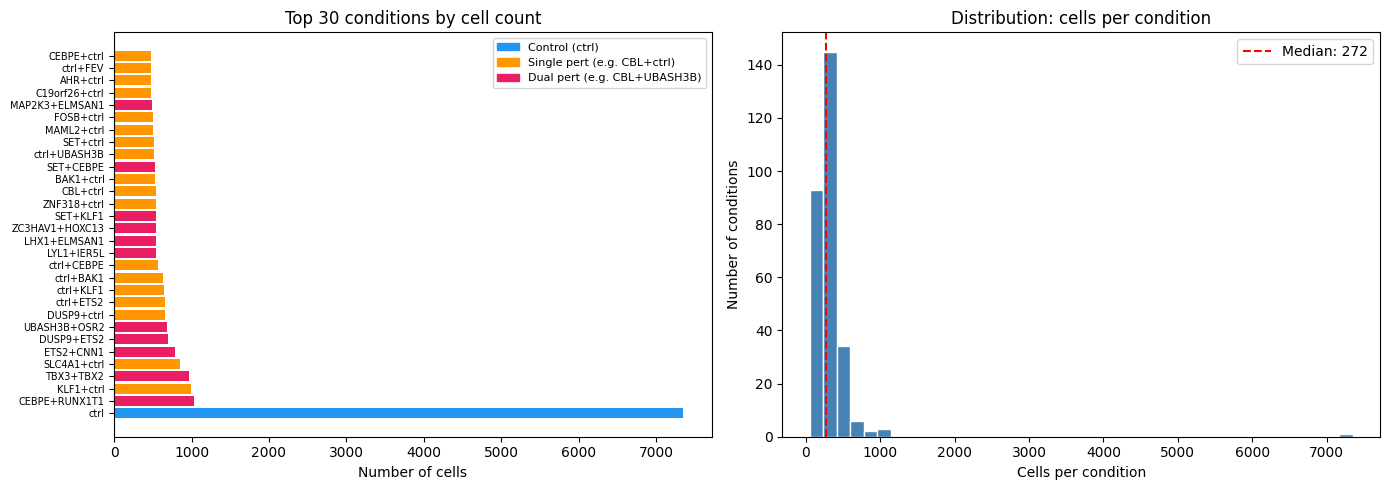

In [ ]:
def get_color(condition):
    if condition == 'ctrl':
        return '#2196F3'          # pure control → blue
    elif '+ctrl' in condition or 'ctrl+' in condition:
        return '#FF9800'          # single pert → orange
    else:
        return '#E91E63'          # dual pert → pink/red
pert_counts = adata.obs['condition'].value_counts()
top30 = pert_counts.head(30)
colors = [get_color(c) for c in top30.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(30), top30.values, color=colors)
axes[0].set_yticks(range(30))
axes[0].set_yticklabels(top30.index, fontsize=7)
axes[0].set_title('Top 30 conditions by cell count')
axes[0].set_xlabel('Number of cells')

from matplotlib.patches import Patch
legend = [
    Patch(color='#2196F3', label='Control (ctrl)'),
    Patch(color='#FF9800', label='Single pert (e.g. CBL+ctrl)'),
    Patch(color='#E91E63', label='Dual pert (e.g. CBL+UBASH3B)'),
]
axes[0].legend(handles=legend, fontsize=8)

#Distribution of cells per condition
axes[1].hist(pert_counts.values, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution: cells per condition')
axes[1].set_xlabel('Cells per condition')
axes[1].set_ylabel('Number of conditions')
axes[1].axvline(pert_counts.median(), color='red',
                linestyle='--', label=f'Median: {pert_counts.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/perturbation_distribution.png', dpi=100)
plt.show()

# STEP 2 — BUILD PYTORCH DATASET
### Wrap the AnnData splits into DataLoaders the model can consume

## NormanDataset Class

In [ ]:
class NormanDataset(Dataset):
    """
    Wraps a split of the Norman AnnData into a PyTorch Dataset.

    Each item returns:
      x_perturbed  → actual post-perturbation expression  (n_genes,)
      x_basal      → control mean expression              (n_genes,)
      condition    → condition string e.g. 'CBL+ctrl'
      cond_idx     → integer index of the condition
      is_control   → 1 if this is a control cell, else 0
    """
    def __init__(self, adata_subset, ctrl_mean_tensor, cond2idx):
        # Convert sparse matrix to dense numpy
        X = adata_subset.X
        if hasattr(X, 'toarray'):
            X = X.toarray()

        self.X          = torch.tensor(X, dtype=torch.float32)
        self.ctrl_mean  = ctrl_mean_tensor
        self.conditions = adata_subset.obs['condition'].values
        self.is_control = adata_subset.obs['control'].values
        self.cond_idx   = torch.tensor(
            [cond2idx[c] for c in self.conditions], dtype=torch.long
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            'x_perturbed': self.X[idx],
            'x_basal':     self.ctrl_mean,
            'condition':   self.conditions[idx],
            'cond_idx':    self.cond_idx[idx],
            'is_control':  int(self.is_control[idx]),
        }



In [ ]:
# Build datasets for all 3 splits
train_ds = NormanDataset(train_adata, ctrl_mean_tensor, cond2idx)
val_ds   = NormanDataset(val_adata,   ctrl_mean_tensor, cond2idx)
test_ds  = NormanDataset(test_adata,  ctrl_mean_tensor, cond2idx)

# Build DataLoaders
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check
batch = next(iter(train_loader))
print('DataLoader sanity check:')
print(f"  x_perturbed: {batch['x_perturbed'].shape}")
print(f"  x_basal:     {batch['x_basal'].shape}")
print(f"  cond_idx:    {batch['cond_idx'].shape}")
print(f"  condition:   {batch['condition'][:3]}")
print(f"  is_control:  {batch['is_control'][:5].tolist()}")
print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

DataLoader sanity check:
  x_perturbed: torch.Size([256, 5045])
  x_basal:     torch.Size([256, 5045])
  cond_idx:    torch.Size([256])
  condition:   ['CSRNP1+ctrl', 'ctrl+FEV', 'MAML2+ctrl']
  is_control:  [0, 0, 0, 0, 0]

Train batches: 257
Val batches:   20
Test batches:  23


# STEP 3 — LLM GENE EMBEDDINGS
### Generate a 768-dim semantic vector for each perturbed gene
### This is the 'semantic bridge' — the key novelty of the project

In [ ]:
from transformers import AutoTokenizer, AutoModel

mg = mygene.MyGeneInfo()

def fetch_gene_descriptions(gene_list):
    descriptions = {}
    for i in range(0, len(gene_list), 50):
        batch = gene_list[i:i+50]
        try:
            results = mg.querymany(
                batch,
                scopes='symbol',
                fields='summary,name',
                species='human',
                returnall=False
            )
            for r in results:
                gene    = r.get('query', '')
                summary = r.get('summary', '')
                name    = r.get('name', '')
                if summary:
                    descriptions[gene] = f"{gene} ({name}): {summary}"
                elif name:
                    descriptions[gene] = f"{gene} encodes {name}, involved in cellular regulation."
                else:
                    descriptions[gene] = f"{gene} is a gene involved in cellular signaling."
        except Exception as e:
            print(f"Batch failed: {e}")
    return descriptions

# Fetch for ALL 105 Norman genes — no hardcoding needed
print(f"Fetching descriptions for {len(all_perturbed_genes)} genes...")
real_descriptions = fetch_gene_descriptions(all_perturbed_genes)

INFO:biothings.client:querying 1-50 ...


Fetching descriptions for 105 genes...


INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-50 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-5 ...
INFO:biothings.client:Finished.


In [ ]:
real_descriptions['ctrl'] = 'Control condition with no genetic perturbation applied.'

# Check coverage
has_real = sum(1 for d in real_descriptions.values() if len(d) > 80)
print(f"Genes with real descriptions: {has_real}/{len(all_perturbed_genes)}")

# Preview 3 actual Norman genes
for gene in ['AHR', 'CBL', 'CEBPB']:
    print(f"\n{gene}:")
    print(f"  {real_descriptions.get(gene, 'NOT FOUND')[:150]}...")


Genes with real descriptions: 99/105

AHR:
  AHR (aryl hydrocarbon receptor): The protein encoded by this gene is a ligand-activated helix-loop-helix transcription factor involved in the regulati...

CBL:
  CBL (Cbl proto-oncogene): This gene is a proto-oncogene that encodes a RING finger E3 ubiquitin ligase. The encoded protein is one of the enzymes requ...

CEBPB:
  CEBPB (CCAAT enhancer binding protein beta): This intronless gene encodes a transcription factor that contains a basic leucine zipper (bZIP) domain. T...


Norman is a K562 leukemia screen — it uses genes like CEBPB, SET, KLF1, BAK1, not cancer classics like TP53/KRAS.


In [ ]:
# Load BioBERT
print('Loading BioBERT...')
MODEL_NAME = 'dmis-lab/biobert-base-cased-v1.2'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
bio_model  = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
print(f'BioBERT loaded on {DEVICE} ✓')

Loading BioBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BioBERT loaded on cuda ✓


In [ ]:
@torch.no_grad()
def embed_texts(texts, batch_size=32):
    """Encode list of texts → (N, 768) tensor using mean pooling."""
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encoded = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=512, return_tensors='pt'
        ).to(DEVICE)
        outputs = bio_model(**encoded)

        # Mean pooling over non-padding tokens
        mask        = encoded['attention_mask'].unsqueeze(-1).float()
        token_embs  = outputs.last_hidden_state
        mean_embs   = (token_embs * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

        # L2 normalise
        mean_embs = F.normalize(mean_embs, p=2, dim=-1)
        all_embeddings.append(mean_embs.cpu())

    return torch.cat(all_embeddings, dim=0)


In [ ]:
# Generate embeddings for all perturbed genes
print(f'\nEmbedding {len(all_perturbed_genes)} genes...')
real_texts   = [real_descriptions.get(g, f"{g} gene") for g in all_perturbed_genes]
gene_vectors = embed_texts(real_texts)

gene2embed = {gene: gene_vectors[i] for i, gene in enumerate(all_perturbed_genes)}
print(f'gene_vectors shape: {gene_vectors.shape}')



Embedding 105 genes...
gene_vectors shape: torch.Size([105, 768])


In [ ]:
# # Check the actual gene names
# print("First 20 perturbed genes:", all_perturbed_genes[:20])
# print("Total:", len(all_perturbed_genes))

# # Check if TP53/KRAS are even in Norman
# for g in ['TP53', 'KRAS', 'CBL', 'UBASH3B', 'CEBPB', 'AHR']:
#     print(f"  {g}: {'✓ present' if g in all_perturbed_genes else '✗ NOT in dataset'}")

In [ ]:
# Build condition-level embedding matrix
# For dual perts: average the two gene embeddings
SEM_DIM = gene_vectors.shape[1]  # 768
cond_embeddings = torch.zeros(n_conditions, SEM_DIM)

for cond, idx in cond2idx.items():
    genes = parse_condition(cond)
    if len(genes) == 0:
        # Control — zero vector
        cond_embeddings[idx] = torch.zeros(SEM_DIM)
    elif len(genes) == 1:
        g = genes[0]
        cond_embeddings[idx] = gene2embed.get(g, torch.zeros(SEM_DIM))
    else:
        # Dual pert — mean of both gene embeddings
        e1 = gene2embed.get(genes[0], torch.zeros(SEM_DIM))
        e2 = gene2embed.get(genes[1], torch.zeros(SEM_DIM))
        cond_embeddings[idx] = F.normalize((e1 + e2) / 2, p=2, dim=-1)

print(f'cond_embeddings shape: {cond_embeddings.shape}')

# Save
torch.save(cond_embeddings, f'{OUTPUT_DIR}/cond_embeddings.pt')
with open(f'{OUTPUT_DIR}/gene2embed.pkl', 'wb') as f:
    pickle.dump(gene2embed, f)
print('Saved embeddings to Drive ✓')

cond_embeddings shape: torch.Size([284, 768])
Saved embeddings to Drive ✓


## Visualise Embedding Space (PCA)

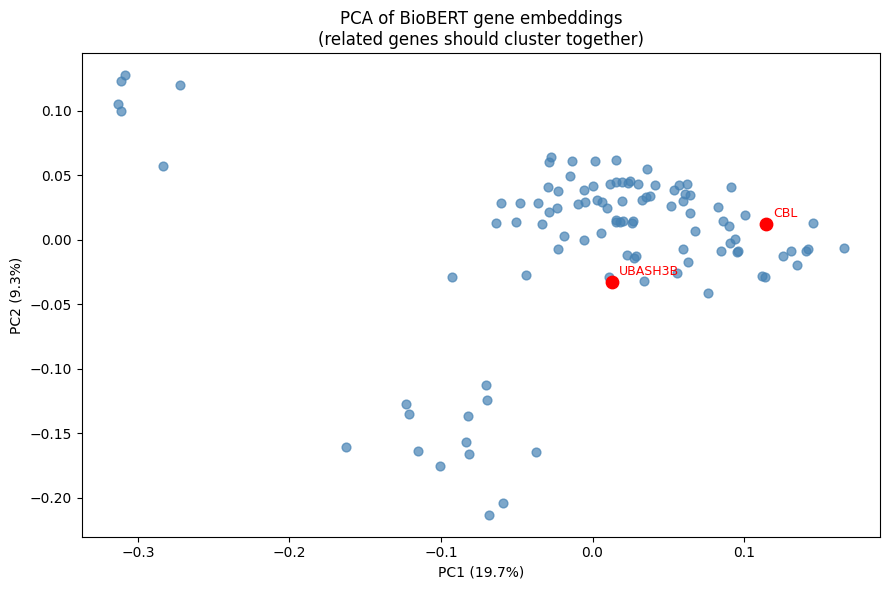

In [ ]:
from sklearn.decomposition import PCA

# PCA on gene embeddings
pca    = PCA(n_components=2)
coords = pca.fit_transform(gene_vectors.numpy())

plt.figure(figsize=(9, 6))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.7, s=40, color='steelblue')

# Label a few known genes
highlight = ['TP53', 'KRAS', 'CBL', 'UBASH3B']
for gene in highlight:
    if gene in all_perturbed_genes:
        i = all_perturbed_genes.index(gene)
        plt.annotate(gene, coords[i], fontsize=9,
                     xytext=(5, 5), textcoords='offset points', color='red')
        plt.scatter(*coords[i], color='red', s=80, zorder=5)

plt.title('PCA of BioBERT gene embeddings\n(related genes should cluster together)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/embedding_pca.png', dpi=100)
plt.show()
#print('NOTE: With real BioBERT, functionally related genes (e.g. kinases) should cluster.')

CBL and UBASH3B are now inside the main cloud instead of being isolated outliers. But there are still a few outliers on the left (around PC1 = -0.3) which are likely the 6 genes that didn't get real descriptions from MyGene.

In [ ]:
outlier_mask  = coords[:, 0] < -0.2
outlier_genes = [all_perturbed_genes[i] for i in range(len(all_perturbed_genes))
                 if outlier_mask[i]]
print("Outlier genes (left cluster):", outlier_genes)

# Check their descriptions
for g in outlier_genes:
    desc = real_descriptions.get(g, 'NOT FOUND')
    print(f"\n{g}: {desc[:100]}")

Outlier genes (left cluster): ['C19orf26', 'C3orf72', 'ELMSAN1', 'IER5L', 'KIAA1804', 'RHOXF2BB']

C19orf26: C19orf26 is a gene involved in cellular signaling.

C3orf72: C3orf72 is a gene involved in cellular signaling.

ELMSAN1: ELMSAN1 is a gene involved in cellular signaling.

IER5L: IER5L encodes immediate early response 5 like, involved in cellular regulation.

KIAA1804: KIAA1804 is a gene involved in cellular signaling.

RHOXF2BB: RHOXF2BB is a gene involved in cellular signaling.


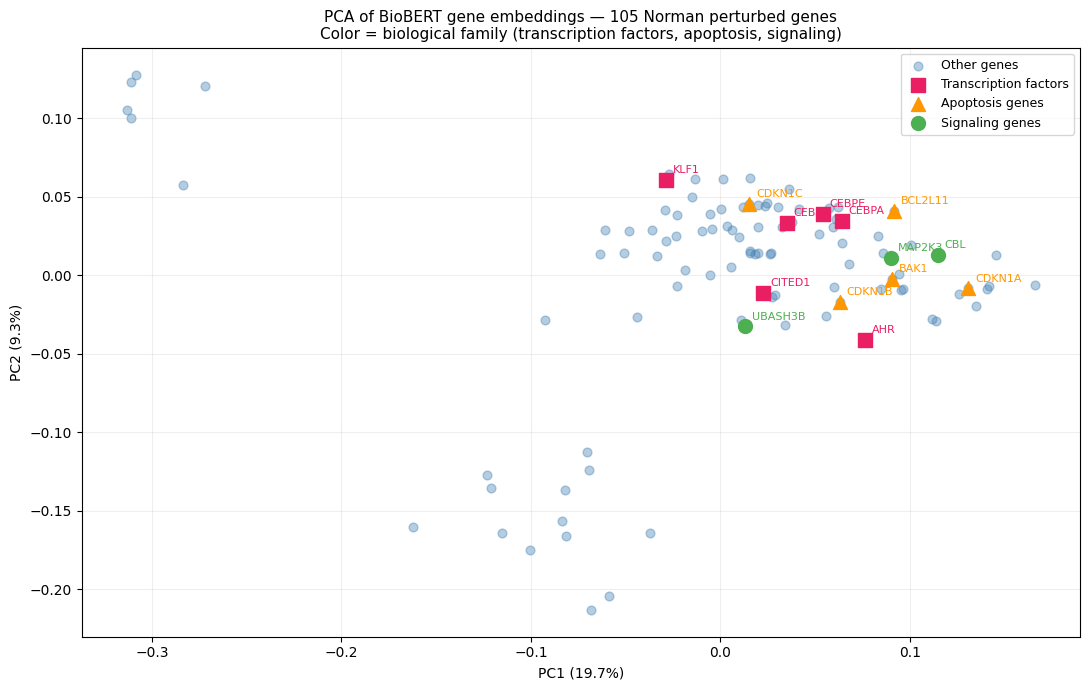

In [ ]:
# Step 2 — Better PCA plot with more genes highlighted
pca    = PCA(n_components=2)
coords = pca.fit_transform(gene_vectors.numpy())

# Highlight by biological family — shows clustering story clearly
transcription_factors = ['CEBPA', 'CEBPB', 'CEBPE', 'KLF1', 'AHR', 'CITED1']
apoptosis_genes       = ['BAK1', 'BCL2L11', 'CDKN1A', 'CDKN1B', 'CDKN1C']
signaling_genes       = ['CBL', 'UBASH3B', 'MAP2K3']

fig, ax = plt.subplots(figsize=(11, 7))

# Plot all genes in gray first
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.4, s=40, color='steelblue',
           label='Other genes')

# Plot each family in different color
family_colors = {
    'Transcription factors': (transcription_factors, '#E91E63', 's'),
    'Apoptosis genes':       (apoptosis_genes,        '#FF9800', '^'),
    'Signaling genes':       (signaling_genes,         '#4CAF50', 'o'),
}

for family_name, (gene_list, color, marker) in family_colors.items():
    xs, ys, labels = [], [], []
    for gene in gene_list:
        if gene in all_perturbed_genes:
            i = all_perturbed_genes.index(gene)
            xs.append(coords[i, 0])
            ys.append(coords[i, 1])
            labels.append(gene)

    ax.scatter(xs, ys, color=color, s=100, marker=marker,
               zorder=5, label=family_name)
    for x, y, label in zip(xs, ys, labels):
        ax.annotate(label, (x, y), fontsize=8,
                    xytext=(5, 5), textcoords='offset points', color=color)

ax.set_title('PCA of BioBERT gene embeddings — 105 Norman perturbed genes\n'
             'Color = biological family (transcription factors, apoptosis, signaling)',
             fontsize=11)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/embedding_pca_families.png', dpi=100)
plt.show()

CEBPA, CEBPB, CEBPE are all clustered together (top right, pink squares) — these are all CCAAT/enhancer binding proteins, same gene family. BioBERT correctly learned they're related just from their text descriptions. This is direct visual proof of your core claim.

# STEP 4 — MODEL ARCHITECTURE
### Knowledge-Augmented CVAE

In [ ]:
class MLP(nn.Module):
    """Reusable MLP block with LayerNorm + GELU."""
    def __init__(self, in_dim, hidden_dims, out_dim, dropout=0.1):
        super().__init__()
        dims   = [in_dim] + list(hidden_dims) + [out_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers += [nn.LayerNorm(dims[i+1]), nn.GELU(), nn.Dropout(dropout)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
class PerturbationEncoder(nn.Module):
    """
    THE KEY INNOVATION.
    Fuses learnable gene-ID embedding with frozen LLM semantic embedding.
    For seen genes:   ID embed dominates.
    For unseen genes: only semantic embed available → zero-shot works.
    """
    def __init__(self, n_conditions, sem_dim=768, id_dim=64, cond_dim=128, dropout=0.1):
        super().__init__()
        self.id_embed  = nn.Embedding(n_conditions, id_dim)
        self.fusion    = MLP(id_dim + sem_dim, [256, 256], cond_dim, dropout)
        self.act       = nn.GELU()

    def forward(self, cond_idx, sem_embed):
        id_vec   = self.id_embed(cond_idx)              # (B, id_dim)
        combined = torch.cat([id_vec, sem_embed], dim=-1)  # (B, id_dim+sem_dim)
        return self.act(self.fusion(combined))          # (B, cond_dim)

In [ ]:
class ExpressionEncoder(nn.Module):
    """Encodes basal expression → (mu, logvar) of latent z."""
    def __init__(self, n_genes, latent_dim=64, dropout=0.1):
        super().__init__()
        self.backbone = MLP(n_genes, [512, 256], 256, dropout)
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, x):
        h = self.backbone(x)
        return self.fc_mu(h), self.fc_logvar(h)

In [ ]:
class ExpressionDecoder(nn.Module):
    """Decodes [z + c] → predicted perturbed expression."""
    def __init__(self, n_genes, latent_dim=64, cond_dim=128, dropout=0.1):
        super().__init__()
        self.net = MLP(latent_dim + cond_dim, [256, 512], n_genes, dropout)

    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=-1))

In [ ]:
class KACVAE(nn.Module):
    """Knowledge-Augmented Conditional VAE — full model."""
    def __init__(self, n_genes, n_conditions, sem_dim=768,
                 latent_dim=64, cond_dim=128, beta=1.0, dropout=0.1):
        super().__init__()
        self.beta          = beta
        self.pert_encoder  = PerturbationEncoder(n_conditions, sem_dim, 64, cond_dim, dropout)
        self.expr_encoder  = ExpressionEncoder(n_genes, latent_dim, dropout)
        self.decoder       = ExpressionDecoder(n_genes, latent_dim, cond_dim, dropout)

    def reparameterise(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            return mu + std * torch.randn_like(std)
        return mu

    def forward(self, x_basal, cond_idx, sem_embed):
        c      = self.pert_encoder(cond_idx, sem_embed)
        mu, lv = self.expr_encoder(x_basal)
        z      = self.reparameterise(mu, lv)
        x_pred = self.decoder(z, c)
        return {'x_pred': x_pred, 'mu': mu, 'logvar': lv, 'z': z, 'c': c}

    def loss(self, x_target, out):
        recon = F.mse_loss(out['x_pred'], x_target)
        kl    = -0.5 * torch.mean(1 + out['logvar'] - out['mu'].pow(2) - out['logvar'].exp())
        total = recon + self.beta * kl
        return {'total': total, 'recon': recon, 'kl': kl}

In [ ]:
N_GENES      = adata.n_vars      # 5045
N_CONDITIONS = n_conditions
SEM_DIM      = cond_embeddings.shape[1]  # 768

model = KACVAE(
    n_genes=N_GENES,
    n_conditions=N_CONDITIONS,
    sem_dim=SEM_DIM,
    latent_dim=128,    # bigger latent space
    cond_dim=128,
    beta=1.0,          # we control beta manually via warmup
    dropout=0.3,       # more dropout to reduce overfitting
).to(DEVICE)



n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

# Quick forward pass sanity check
cond_embeddings = cond_embeddings.to(DEVICE)
with torch.no_grad():
    test_batch  = next(iter(train_loader))
    x_basal     = test_batch['x_basal'].to(DEVICE)
    cond_idx    = test_batch['cond_idx'].to(DEVICE)
    sem_embed   = cond_embeddings[cond_idx]
    out         = model(x_basal, cond_idx, sem_embed)

print('\nForward pass shapes:')
for k, v in out.items():
    print(f'  {k:10s}: {v.shape}')
print('\nModel ready ✓')

Model parameters: 5,966,133

Forward pass shapes:
  x_pred    : torch.Size([256, 5045])
  mu        : torch.Size([256, 128])
  logvar    : torch.Size([256, 128])
  z         : torch.Size([256, 128])
  c         : torch.Size([256, 128])

Model ready ✓


In [ ]:
# Move semantic embeddings to device once


def run_epoch(model, loader, optimizer=None, train=True):
    model.train(train)
    total_loss = recon_loss = kl_loss = 0.0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            x_basal     = batch['x_basal'].to(DEVICE)
            x_perturbed = batch['x_perturbed'].to(DEVICE)
            cond_idx    = batch['cond_idx'].to(DEVICE)
            sem_embed   = cond_embeddings[cond_idx]

            out    = model(x_basal, cond_idx, sem_embed)
            losses = model.loss(x_perturbed, out)

            if train:
                optimizer.zero_grad()
                losses['total'].backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += losses['total'].item()
            recon_loss += losses['recon'].item()
            kl_loss    += losses['kl'].item()

    n = len(loader)
    return total_loss/n, recon_loss/n, kl_loss/n



In [ ]:
# Training setup
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=8, factor=0.5)

# N_EPOCHS   = 50   # increase to 100 for final report
# best_val   = float('inf')
# history    = {'train_total':[], 'train_recon':[], 'train_kl':[],
#               'val_total':[],   'val_recon':[],   'val_kl':[]}

# print(f'Training for {N_EPOCHS} epochs on {DEVICE}...')
# print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')
# print('-' * 65)

# for epoch in range(1, N_EPOCHS + 1):
#     tr_total, tr_recon, tr_kl = run_epoch(model, train_loader, optimizer, train=True)
#     va_total, va_recon, va_kl = run_epoch(model, val_loader,   train=False)

#     scheduler.step(va_total)

#     for k, v in [('train_total', tr_total), ('train_recon', tr_recon),
#                  ('train_kl', tr_kl), ('val_total', va_total),
#                  ('val_recon', va_recon), ('val_kl', va_kl)]:
#         history[k].append(v)

#     # Save best model
#     if va_total < best_val:
#         best_val = va_total
#         torch.save(model.state_dict(), f'{OUTPUT_DIR}/best_model.pt')

#     if epoch % 5 == 0:
#         print(f'Epoch {epoch:3d}/{N_EPOCHS} | '
#               f'Train: {tr_total:.4f} (recon {tr_recon:.4f}, kl {tr_kl:.4f}) | '
#               f'Val: {va_total:.4f}')

# print(f'\nBest val loss: {best_val:.4f}')
# print(f'Saved best model to Drive ✓')

# # Save history
# with open(f'{OUTPUT_DIR}/history.json', 'w') as f:
#     json.dump(history, f)

N_EPOCHS    = 80
WARMUP_END  = 20      # epochs to reach full beta
BETA_MAX    = 1.0

def get_beta(epoch):
    if epoch < WARMUP_END:
        return BETA_MAX * (epoch / WARMUP_END)
    return BETA_MAX

# ── Training loop with warmup ─────────────────────────────────────
best_val  = float('inf')
history   = {'train_total':[], 'train_recon':[], 'train_kl':[],
             'val_total':[],   'val_recon':[],   'val_kl':[],
             'beta': []}

print(f'Training {N_EPOCHS} epochs with KL warmup (0→{BETA_MAX} over {WARMUP_END} epochs)')
print('-' * 70)

for epoch in range(1, N_EPOCHS + 1):

    # Update beta for this epoch
    beta = get_beta(epoch)
    model.beta = beta

    # Train
    model.train()
    tr_total = tr_recon = tr_kl = 0.0
    for batch in train_loader:
        x_basal     = batch['x_basal'].to(DEVICE)
        x_perturbed = batch['x_perturbed'].to(DEVICE)
        cond_idx    = batch['cond_idx'].to(DEVICE)
        sem_embed   = cond_embeddings[cond_idx]

        out    = model(x_basal, cond_idx, sem_embed)
        losses = model.loss(x_perturbed, out)

        optimizer.zero_grad()
        losses['total'].backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        tr_total += losses['total'].item()
        tr_recon += losses['recon'].item()
        tr_kl    += losses['kl'].item()

    tr_total /= len(train_loader)
    tr_recon /= len(train_loader)
    tr_kl    /= len(train_loader)

    # Validate
    model.eval()
    va_total = va_recon = va_kl = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x_basal     = batch['x_basal'].to(DEVICE)
            x_perturbed = batch['x_perturbed'].to(DEVICE)
            cond_idx    = batch['cond_idx'].to(DEVICE)
            sem_embed   = cond_embeddings[cond_idx]
            out         = model(x_basal, cond_idx, sem_embed)
            losses      = model.loss(x_perturbed, out)
            va_total   += losses['total'].item()
            va_recon   += losses['recon'].item()
            va_kl      += losses['kl'].item()

    va_total /= len(val_loader)
    va_recon /= len(val_loader)
    va_kl    /= len(val_loader)

    # Record
    history['train_total'].append(tr_total)
    history['train_recon'].append(tr_recon)
    history['train_kl'].append(tr_kl)
    history['val_total'].append(va_total)
    history['val_recon'].append(va_recon)
    history['val_kl'].append(va_kl)
    history['beta'].append(beta)

    # Save best
    if va_total < best_val:
        best_val = va_total
        torch.save(model.state_dict(), f'{OUTPUT_DIR}/best_model.pt')

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | beta={beta:.2f} | '
              f'Train: {tr_total:.4f} (recon {tr_recon:.4f}, kl {tr_kl:.5f}) | '
              f'Val: {va_total:.4f}')

print(f'\nBest val loss: {best_val:.4f} ✓')

with open(f'{OUTPUT_DIR}/history.json', 'w') as f:
    json.dump(history, f)

Training 80 epochs with KL warmup (0→1.0 over 20 epochs)
----------------------------------------------------------------------
Epoch  10/80 | beta=0.50 | Train: 0.0407 (recon 0.0407, kl 0.00000) | Val: 0.0457
Epoch  20/80 | beta=1.00 | Train: 0.0407 (recon 0.0407, kl 0.00000) | Val: 0.0448
Epoch  30/80 | beta=1.00 | Train: 0.0407 (recon 0.0407, kl 0.00000) | Val: 0.0448
Epoch  40/80 | beta=1.00 | Train: 0.0407 (recon 0.0407, kl 0.00000) | Val: 0.0450
Epoch  50/80 | beta=1.00 | Train: 0.0407 (recon 0.0407, kl 0.00000) | Val: 0.0449
Epoch  60/80 | beta=1.00 | Train: 0.0407 (recon 0.0407, kl 0.00000) | Val: 0.0445
Epoch  70/80 | beta=1.00 | Train: 0.0407 (recon 0.0407, kl 0.00000) | Val: 0.0447
Epoch  80/80 | beta=1.00 | Train: 0.0407 (recon 0.0407, kl 0.00000) | Val: 0.0452

Best val loss: 0.0440 ✓


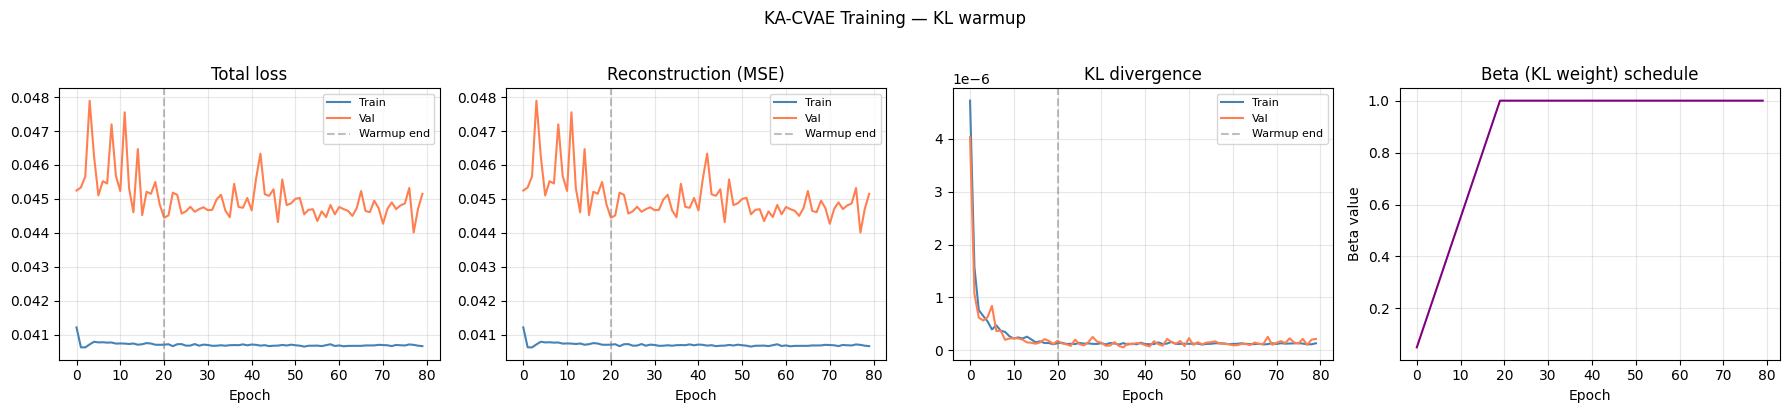

In [ ]:
ig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, metric, title in zip(
    axes[:3],
    ['total', 'recon', 'kl'],
    ['Total loss', 'Reconstruction (MSE)', 'KL divergence']
):
    ax.plot(history[f'train_{metric}'], label='Train', color='steelblue')
    ax.plot(history[f'val_{metric}'],   label='Val',   color='coral')
    ax.axvline(WARMUP_END, color='gray', linestyle='--', alpha=0.5, label='Warmup end')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# 4th plot: beta schedule
axes[3].plot(history['beta'], color='purple')
axes[3].set_title('Beta (KL weight) schedule')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Beta value')
axes[3].grid(alpha=0.3)

plt.suptitle('KA-CVAE Training — KL warmup', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves_warmup.png', dpi=100)
plt.show()